In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Al_5:30_pm /Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.shape

(891, 12)

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Different classes likely had different age distributions
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  202 non-null    int64  
 1   Survived     202 non-null    int64  
 2   Pclass       202 non-null    int64  
 3   Name         202 non-null    object 
 4   Sex          202 non-null    object 
 5   Age          202 non-null    float64
 6   SibSp        202 non-null    int64  
 7   Parch        202 non-null    int64  
 8   Ticket       202 non-null    object 
 9   Fare         202 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     202 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 20.5+ KB


In [ ]:
# Create new features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
auto = df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Survived']]
auto

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Survived
1,1,female,38.0,71.2833,C,2,0,1
3,1,female,35.0,53.1000,S,2,0,1
6,1,male,54.0,51.8625,S,1,1,0
10,3,female,4.0,16.7000,S,3,0,1
11,1,female,58.0,26.5500,S,1,1,1
...,...,...,...,...,...,...,...,...
871,1,female,47.0,52.5542,S,3,0,1
872,1,male,33.0,5.0000,S,1,1,0
879,1,female,56.0,83.1583,C,2,0,1
887,1,female,19.0,30.0000,S,1,1,1


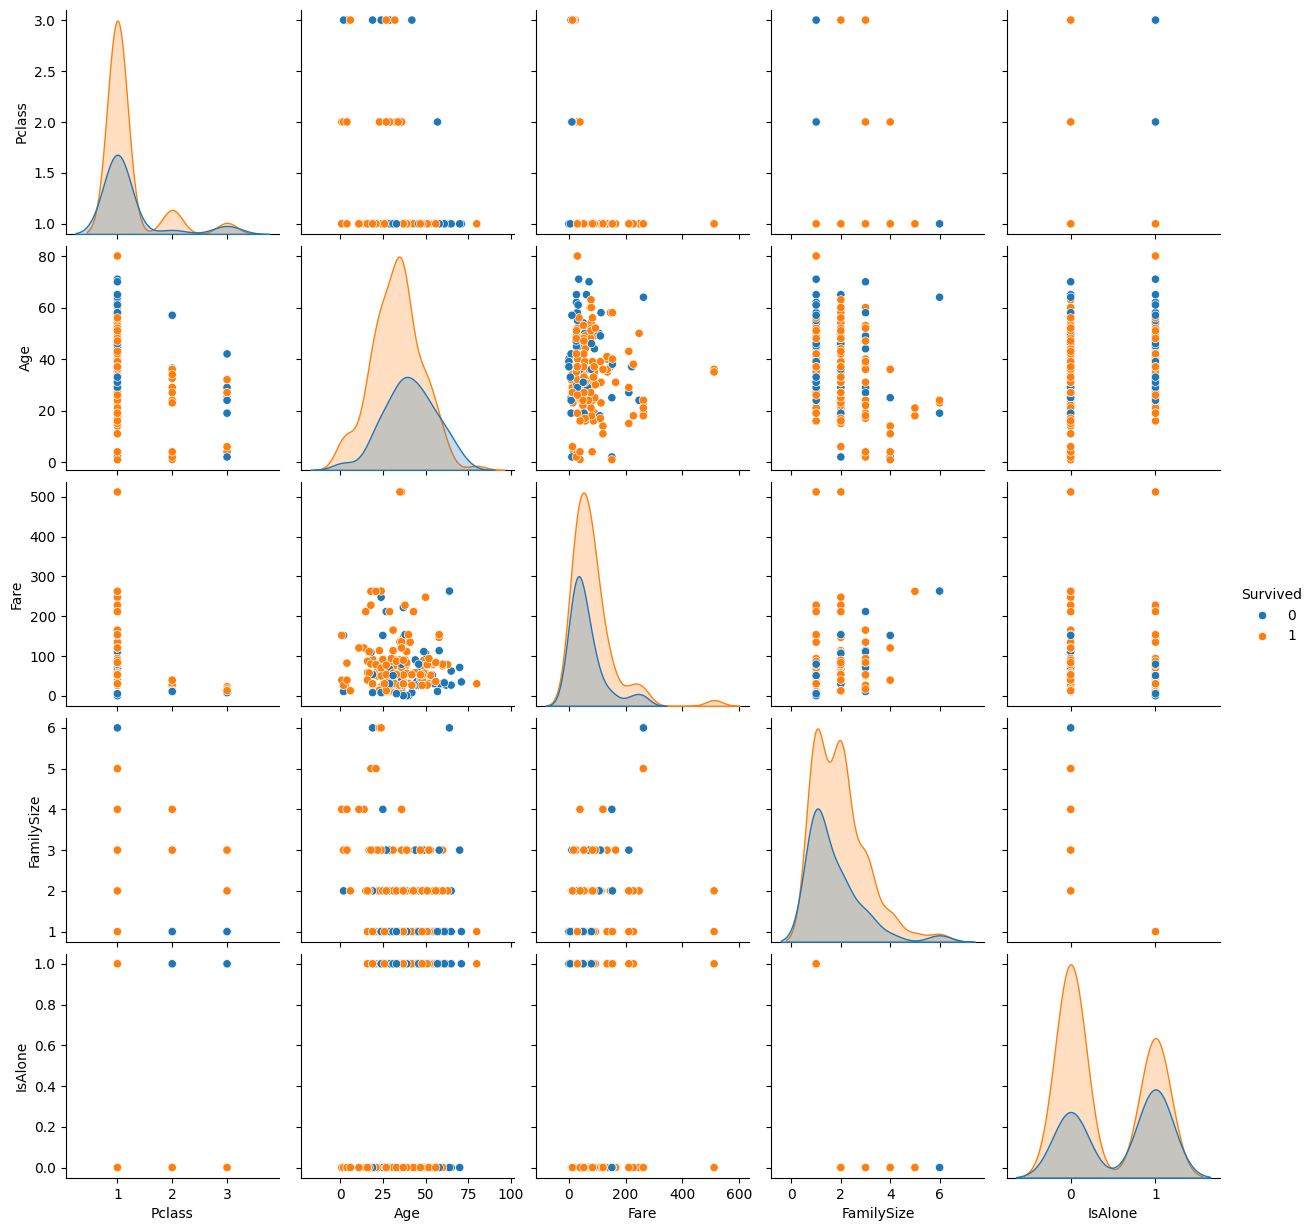

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(auto, hue='Survived')

In [ ]:
auto1 = df[['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Survived']]
auto1.corr()

,Pclass,Age,Fare,FamilySize,IsAlone,Survived
Pclass,1.000000,-0.315924,-0.311740,-0.012555,0.052489,-0.030513
Age,-0.315924,1.000000,-0.082916,-0.269593,0.194699,-0.239720
Fare,-0.311740,-0.082916,1.000000,0.429595,-0.306860,0.128261
FamilySize,-0.012555,-0.269593,0.429595,1.000000,-0.749149,0.109019
IsAlone,0.052489,0.194699,-0.306860,-0.749149,1.000000,-0.168909
Survived,-0.030513,-0.239720,0.128261,0.109019,-0.168909,1.000000


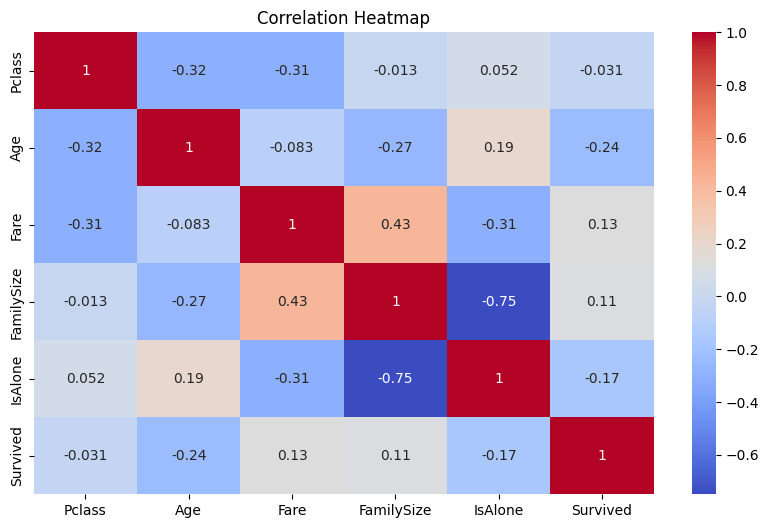

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(auto1.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# encoding of feature

In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [ ]:
df = pd.get_dummies(
    df,
    columns=['Embarked', 'Pclass'],
    drop_first=True
)

In [ ]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X

,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
1,1,38.0,1,0,71.2833,2,0,35.641650,False,False,False,False
3,1,35.0,1,0,53.1000,2,0,26.550000,False,True,False,False
6,0,54.0,0,0,51.8625,1,1,51.862500,False,True,False,False
10,1,4.0,1,1,16.7000,3,0,5.566667,False,True,False,True
11,1,58.0,0,0,26.5500,1,1,26.550000,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,47.0,1,1,52.5542,3,0,17.518067,False,True,False,False
872,0,33.0,0,0,5.0000,1,1,5.000000,False,True,False,False
879,1,56.0,0,1,83.1583,2,0,41.579150,False,False,False,False
887,1,19.0,0,0,30.0000,1,1,30.000000,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)
print("LogReg Accuracy:", accuracy_score(y_val, y_pred))

LogReg Accuracy: 0.7073170731707317


In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
0,Sex,2.545543
10,Pclass_2,0.363013
2,SibSp,0.185914
7,FarePerPerson,0.011007
4,Fare,-0.006996
5,FamilySize,-0.014659
1,Age,-0.036250
9,Embarked_S,-0.065666
3,Parch,-0.201806
11,Pclass_3,-0.325474


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
print("RF Accuracy:", accuracy_score(y_val, y_pred_rf))

RF Accuracy: 0.7073170731707317


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt_model = dt.fit(X_train, y_train)
print("DTC Accuracy:", accuracy_score(y_val, y_pred_rf))

DTC Accuracy: 0.7073170731707317


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[[ 8  6]
 [ 6 21]]
              precision    recall  f1-score   support

           0       0.57      0.57      0.57        14
           1       0.78      0.78      0.78        27

    accuracy                           0.71        41
   macro avg       0.67      0.67      0.67        41
weighted avg       0.71      0.71      0.71        41



In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = rf.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.761904761904762


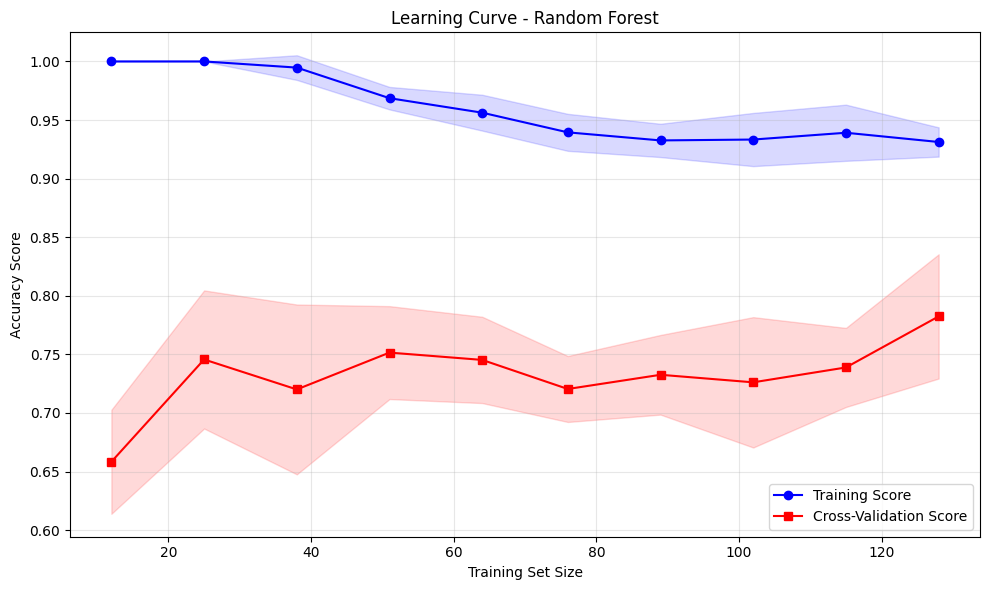

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, model_name):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training Score', color='blue', marker='o')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    plt.plot(train_sizes, val_mean, label='Cross-Validation Score', color='red', marker='s')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')

    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title(f'Learning Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot for your best model
plot_learning_curve(rf, X_train, y_train, 'Random Forest')

In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC for Random Forest model
y_val_proba = rf.predict_proba(X_val)[:, 1]
print("Random Forest ROC-AUC:", roc_auc_score(y_val, y_val_proba))

Random Forest ROC-AUC: 0.761904761904762


In [ ]:
import joblib

# 1️⃣ Save trained model
joblib.dump(rf, 'titanic_rf_model.joblib')

# 2️⃣ Save feature schema (CRITICAL)
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'titanic_feature_names.joblib')

print("✅ Model and feature schema saved successfully")


✅ Model and feature schema saved successfully


In [ ]:
# Compress files for easy download
import shutil
shutil.make_archive('titanic_model', 'zip', '.', 'titanic_rf_model.joblib')
shutil.make_archive('titanic_features', 'zip', '.', 'titanic_feature_names.joblib')

# Download them
from google.colab import files
files.download('titanic_rf_model.joblib')
files.download('titanic_feature_names.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>